# 06 — Evolucion temporal de la contratacion y estabilidad de los indicadores

**Proposito.** Cerrar la brecha 4 del documento comparativo: el filtro 2018-2024 se aplico sin ninguna
figura que mostrara la distribucion de la muestra por anio. Este cuaderno responde tres preguntas que un
jurado formulara: cuantos contratos aporta cada anio, si el corte de 2024 trunca contratos largos, y si
los indicadores de desempeno son estables en el tiempo o si el resultado global esta dominado por un
periodo concreto.

**Insumo.** `data/universo_extendido.parquet` (notebook 01).

**Etiquetas de objetivo que atiende:** `[A-OE04]` (visualizacion y segmentacion temporal),
`[A-OE03]` (validez del criterio temporal de inclusion), `[B-OE2]` (caracterizacion del comportamiento
historico, que es literalmente el enunciado del objetivo), `[CALIDAD]`.

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
BASE_EDA = _p.parent if _p.name == "notebooks" else _p
sys.path.insert(0, str(BASE_EDA / "src"))

import numpy as np
import pandas as pd
from scipy import stats
from eda_comun import *

plt, CMAP_SEQ, CMAP_DIV = configurar_matplotlib()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Modulo propio eda_comun cargado desde:", BASE_EDA / "src")
print("Alfa declarado a priori:", ALFA)

Modulo propio eda_comun cargado desde: /home/william-telles/Documentos/extraccion-datos-secop2-main (1)/extraccion-datos-secop2-main/eda-extendido-integral/src
Alfa declarado a priori: 0.05


In [2]:
df = pd.read_parquet(DIR_DATA / "universo_extendido.parquet")
df["fecha_firma"] = pd.to_datetime(df["fecha_de_firma"], errors="coerce")
obs = df[df["observable"]].copy()
print(f"Universo: {len(df):,} | Observable: {len(obs):,}")
print(f"Rango de fecha_de_firma en el universo: {df['fecha_firma'].min().date()} a {df['fecha_firma'].max().date()}")
print(f"Contratos sin fecha de firma: {int(df['fecha_firma'].isna().sum()):,}")

Universo: 48,331 | Observable: 19,194
Rango de fecha_de_firma en el universo: 2016-09-23 a 2026-02-26
Contratos sin fecha de firma: 5,150


## 1. Distribucion anual y efecto del criterio temporal de inclusion

In [3]:
marcar("anual")

anual = df.groupby("anio_firma").agg(
    contratos_universo=("id_contrato", "size"),
    observables=("observable", "sum"),
    valor_mediano=("valor_del_contrato", "median"),
)
anual = anual[anual.index.notna()]
anual.index = anual.index.astype(int)
anual["retencion_pct"] = (anual["observables"] / anual["contratos_universo"] * 100).round(2)
anual["pct_del_universo"] = (anual["contratos_universo"] / len(df) * 100).round(2)
anual["dentro_de_2018_2024"] = [(2018 <= a <= 2024) for a in anual.index]
print(anual.to_string())
print()
fuera = anual.loc[~anual["dentro_de_2018_2024"], "contratos_universo"].sum()
sinfecha = int(df["anio_firma"].isna().sum())
print(f"Contratos fuera de la ventana 2018-2024: {fuera:,} ({fuera/len(df)*100:.2f}% del universo)")
print(f"Contratos sin anio de firma: {sinfecha:,} ({sinfecha/len(df)*100:.2f}%)")
print(f"Total excluido por el criterio temporal: {fuera + sinfecha:,}")
print()
print("Composicion de lo excluido por el criterio temporal:")
excl = df[~df["anio_firma"].between(2018, 2024) | df["anio_firma"].isna()]
print(f"  posteriores a 2024: {int((excl['anio_firma'] > 2024).sum()):,}")
print(f"  anteriores a 2018:  {int((excl['anio_firma'] < 2018).sum()):,}")
print(f"  sin fecha:          {sinfecha:,}")
print()
print("Hallazgo: la mayor parte de lo excluido por el criterio temporal NO son contratos antiguos sino")
print("contratos firmados DESPUES del cierre de la ventana. El criterio 2018-2024 del anteproyecto no")
print("descarta historia: descarta contratacion reciente aun no observable.")

            contratos_universo  observables    valor_mediano  retencion_pct  pct_del_universo  dentro_de_2018_2024
anio_firma                                                                                                        
2016                         7            0  70,909,904.0000         0.0000            0.0100                False
2017                       237            0 168,625,969.0000         0.0000            0.4900                False
2018                      1282          854 176,256,431.5000        66.6100            2.6500                 True
2019                      2292         1559 207,251,481.0000        68.0200            4.7400                 True
2020                      2764         1725 399,998,387.5000        62.4100            5.7200                 True
2021                      5406         3274 239,061,621.5000        60.5600           11.1900                 True
2022                      5962         3680 284,161,402.5000        61.7200     

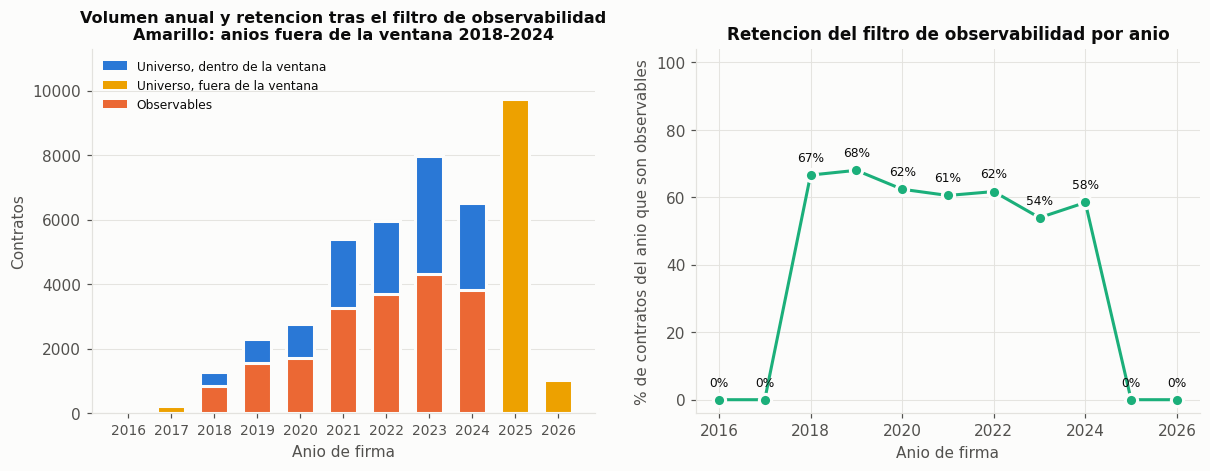

Figura persistida: 06_distribucion_anual.png


In [4]:
marcar("fig_anual")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

ax = axes[0]
x = np.arange(len(anual))
colores = [PALETA[0] if d else PALETA[3] for d in anual["dentro_de_2018_2024"]]
ax.bar(x, anual["contratos_universo"], color=colores, width=0.65, edgecolor=SURFACE, linewidth=2,
       label="Universo completo")
ax.bar(x, anual["observables"], color=PALETA[1], width=0.65, edgecolor=SURFACE, linewidth=2,
       label="Observables")
ax.set_xticks(x); ax.set_xticklabels(anual.index, fontsize=9)
ax.set_ylabel("Contratos")
ax.set_xlabel("Anio de firma")
ax.set_title("Volumen anual y retencion tras el filtro de observabilidad\n"
             "Amarillo: anios fuera de la ventana 2018-2024", fontsize=10.5)
ax.set_ylim(0, anual["contratos_universo"].max() * 1.16)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=PALETA[0], label="Universo, dentro de la ventana"),
                   Patch(facecolor=PALETA[3], label="Universo, fuera de la ventana"),
                   Patch(facecolor=PALETA[1], label="Observables")],
          fontsize=8, loc="upper left", ncol=1)
ax.xaxis.grid(False); ax.set_axisbelow(True)

ax = axes[1]
ax.plot(anual.index, anual["retencion_pct"], marker="o", lw=2, ms=8,
        color=PALETA[2], markeredgecolor=SURFACE, markeredgewidth=2)
for a, v in zip(anual.index, anual["retencion_pct"]):
    ax.annotate(f"{v:.0f}%", (a, v), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=8, color=TEXT_1)
ax.set_ylabel("% de contratos del anio que son observables")
ax.set_xlabel("Anio de firma")
ax.set_ylim(-4, 104)
ax.set_title("Retencion del filtro de observabilidad por anio", fontsize=11)
ax.set_axisbelow(True)
guardar_mostrar(fig, "06_distribucion_anual.png")

## 2. Truncamiento del corte de 2024

Un contrato firmado a finales de 2024 con plazo largo no puede haber terminado. Si el filtro de
observabilidad retiene sistematicamente los contratos cortos de los ultimos anios, el subconjunto
observable esta sesgado hacia contratos de menor duracion en esos anios, y el indicador de tiempo lo
refleja. Se cuantifica.

In [5]:
marcar("truncamiento")

trunc = (df[df["anio_firma"].between(2018, 2024)]
         .groupby("anio_firma")
         .agg(n_universo=("id_contrato", "size"),
              n_observable=("observable", "sum"),
              plazo_mediano_universo=("plazo_pactado_dias", "median"),
              plazo_mediano_observable=("plazo_pactado_dias", lambda s: np.nan)))
obs_g = obs[obs["anio_firma"].between(2018, 2024)].groupby("anio_firma")
trunc["plazo_mediano_observable"] = obs_g["plazo_pactado_dias"].median()
trunc["valor_mediano_universo"] = df[df["anio_firma"].between(2018, 2024)].groupby("anio_firma")["valor_del_contrato"].median()
trunc["valor_mediano_observable"] = obs_g["valor_del_contrato"].median()
trunc["retencion_pct"] = (trunc["n_observable"] / trunc["n_universo"] * 100).round(1)
trunc["dif_plazo_pp"] = (trunc["plazo_mediano_observable"] - trunc["plazo_mediano_universo"]).round(1)
trunc.index = trunc.index.astype(int)
print(trunc.to_string())
print()
print("Lectura del truncamiento: si el filtro sesgara hacia contratos cortos en los anios recientes,")
print("la diferencia de plazo mediano (observable - universo) seria crecientemente negativa hacia 2024.")
print()
sp = spearman(trunc.index.to_series(), trunc["dif_plazo_pp"])
print(f"Spearman anio ~ diferencia de plazo mediano: rho = {sp['rho']:.3f}, "
      f"p = {fmt_p(sp['p'])}, N efectivo = {sp['n_efectivo']} (solo 7 puntos: es descriptivo, no concluyente)")

            n_universo  n_observable  plazo_mediano_universo  plazo_mediano_observable  valor_mediano_universo  valor_mediano_observable  retencion_pct  dif_plazo_pp
anio_firma                                                                                                                                                           
2018              1282           854                     NaN                       NaN        176,256,431.5000          201,899,806.5000        66.6000           NaN
2019              2292          1559                     NaN                       NaN        207,251,481.0000          244,127,786.0000        68.0000           NaN
2020              2764          1725                 90.0000                  110.0000        399,998,387.5000          541,780,675.0000        62.4000       20.0000
2021              5406          3274                150.0000                  150.5000        239,061,621.5000          203,996,376.0000        60.6000        0.5000
2022

## 3. Estabilidad de los indicadores de desempeno en el tiempo

In [6]:
marcar("estabilidad")

def serie_indicadores(x, etiqueta):
    g = x[x["anio_firma"].between(2018, 2024)].groupby("anio_firma")
    r = pd.DataFrame({
        "n": g.size(),
        "n_ef_tiempo": g["deslizamiento_plazo_dias"].apply(lambda s: int(s.notna().sum())),
        "mediana_deslizamiento": g["deslizamiento_plazo_dias"].median(),
        "pct_retraso_mayor_30": g["deslizamiento_plazo_dias"].apply(
            lambda s: round((s.dropna() > 30).mean() * 100, 1)),
        "n_ef_costo": g["desviacion_costo_pct"].apply(lambda s: int(s.notna().sum())),
        "mediana_costo": g["desviacion_costo_pct"].median().round(3),
        "pct_no_entregado": g["indice_alcance"].apply(lambda s: round((s == "No entregado").mean() * 100, 1)),
        "mediana_oferentes": g["n_oferentes"].median(),
    })
    r.index = r.index.astype(int)
    r["lectura"] = etiqueta
    return r

est_uni = serie_indicadores(df, "universo_completo")
est_obs = serie_indicadores(obs, "observable")
print("=== UNIVERSO COMPLETO ==="); print(est_uni.drop(columns="lectura").to_string())
print()
print("=== SUBCONJUNTO OBSERVABLE ==="); print(est_obs.drop(columns="lectura").to_string())
pd.concat([est_uni, est_obs]).to_csv(DIR_DATA / "indicadores_por_anio.csv")

sub = obs[obs["anio_firma"].between(2018, 2024)]
g = {int(k): v["deslizamiento_plazo_dias"].dropna() for k, v in sub.groupby("anio_firma")}
print()
print("Kruskal-Wallis, deslizamiento del plazo entre anios (observable):")
print(" ", resumen_prueba(kruskal(g)))
g2 = {int(k): v["desviacion_costo_pct"].dropna() for k, v in sub.groupby("anio_firma")}
print("Kruskal-Wallis, desviacion de costo entre anios (observable):")
print(" ", resumen_prueba(kruskal(g2)))

=== UNIVERSO COMPLETO ===
               n  n_ef_tiempo  mediana_deslizamiento  pct_retraso_mayor_30  n_ef_costo  mediana_costo  pct_no_entregado  mediana_oferentes
anio_firma                                                                                                                                
2018        1282            0                    NaN                   NaN         248        -0.0000           36.7000             5.0000
2019        2292            0                    NaN                   NaN         485         0.0000           29.0000             6.0000
2020        2764         2185                 3.0000               36.4000         611         0.0000           19.9000             5.0000
2021        5406         5309                 4.0000               37.8000        2181         0.0000           21.9000             1.0000
2022        5962         5830                 3.0000               35.3000        2573        -0.0000           13.8000             1.0000
2


Kruskal-Wallis, deslizamiento del plazo entre anios (observable):
  H = 248.67 | gl = 4 | p = 1.26e-52 | epsilon2 = 0.0150 (debil) | k = 5 grupos | N efectivo = 16,326
Kruskal-Wallis, desviacion de costo entre anios (observable):
  H = 61.67 | gl = 6 | p = 2.06e-11 | epsilon2 = 0.0064 (nulo/insignificante) | k = 7 grupos | N efectivo = 8,681
  ADVERTENCIA: significancia estadistica con tamano de efecto nulo. Con N grande esto NO sostiene la hipotesis.


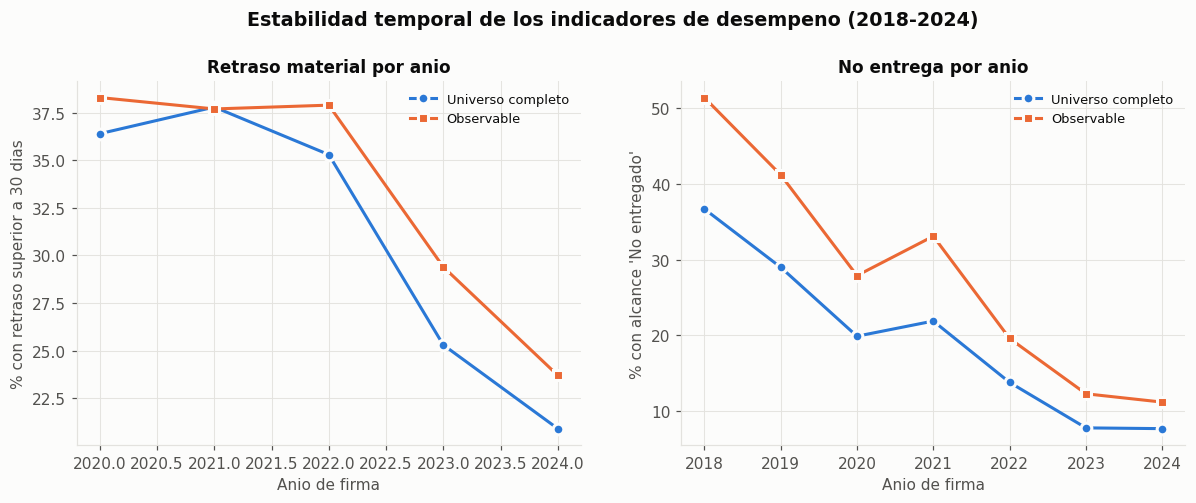

Figura persistida: 06_estabilidad_indicadores.png


In [7]:
marcar("fig_estabilidad")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
ax = axes[0]
ax.plot(est_uni.index, est_uni["pct_retraso_mayor_30"], marker="o", lw=2, ms=7,
        color=PALETA[0], markeredgecolor=SURFACE, markeredgewidth=2, label="Universo completo")
ax.plot(est_obs.index, est_obs["pct_retraso_mayor_30"], marker="s", lw=2, ms=7,
        color=PALETA[1], markeredgecolor=SURFACE, markeredgewidth=2, label="Observable")
ax.set_ylabel("% con retraso superior a 30 dias")
ax.set_xlabel("Anio de firma")
ax.set_title("Retraso material por anio", fontsize=11)
ax.legend(fontsize=8.5); ax.set_axisbelow(True)

ax = axes[1]
ax.plot(est_uni.index, est_uni["pct_no_entregado"], marker="o", lw=2, ms=7,
        color=PALETA[0], markeredgecolor=SURFACE, markeredgewidth=2, label="Universo completo")
ax.plot(est_obs.index, est_obs["pct_no_entregado"], marker="s", lw=2, ms=7,
        color=PALETA[1], markeredgecolor=SURFACE, markeredgewidth=2, label="Observable")
ax.set_ylabel("% con alcance 'No entregado'")
ax.set_xlabel("Anio de firma")
ax.set_title("No entrega por anio", fontsize=11)
ax.legend(fontsize=8.5); ax.set_axisbelow(True)

fig.suptitle("Estabilidad temporal de los indicadores de desempeno (2018-2024)",
             fontsize=12.5, fontweight="bold", y=1.03)
guardar_mostrar(fig, "06_estabilidad_indicadores.png")

## 4. Estacionalidad mensual de la firma de contratos

In [8]:
marcar("estacionalidad")

MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
mensual = (df[df["anio_firma"].between(2018, 2024)]
           .groupby("mes_firma")
           .agg(contratos=("id_contrato", "size"),
                valor_mediano=("valor_del_contrato", "median"),
                pct_observable=("observable", lambda s: round(s.mean() * 100, 1))))
mensual.index = [MESES[int(i) - 1] for i in mensual.index]
mensual["pct_del_total"] = (mensual["contratos"] / mensual["contratos"].sum() * 100).round(2)
print(mensual.to_string())
print()
print(f"Concentracion en el ultimo trimestre (Oct-Dic): "
      f"{mensual.loc[['Oct','Nov','Dic'], 'pct_del_total'].sum():.1f}% de la contratacion anual.")
print(f"Concentracion en el primer trimestre (Ene-Mar): "
      f"{mensual.loc[['Ene','Feb','Mar'], 'pct_del_total'].sum():.1f}%.")

     contratos    valor_mediano  pct_observable  pct_del_total
Ene        477 570,734,289.0000         62.5000         1.4800
Feb        570 349,811,068.5000         58.9000         1.7700
Mar       1071 128,400,000.0000         58.8000         3.3300
Abr       1468 200,000,000.0000         63.1000         4.5600
May       2217 249,883,634.0000         60.6000         6.8900
Jun       2748 212,061,439.5000         58.7000         8.5400
Jul       2584 299,952,030.5000         66.4000         8.0300
Ago       2704 297,785,833.0000         61.2000         8.4000
Sep       3241 254,585,870.0000         63.0000        10.0700
Oct       4029 195,352,670.0000         60.6000        12.5200
Nov       4991 169,534,017.0000         58.0000        15.5100
Dic       6075 212,321,012.0000         54.2000        18.8800

Concentracion en el ultimo trimestre (Oct-Dic): 46.9% de la contratacion anual.
Concentracion en el primer trimestre (Ene-Mar): 6.6%.


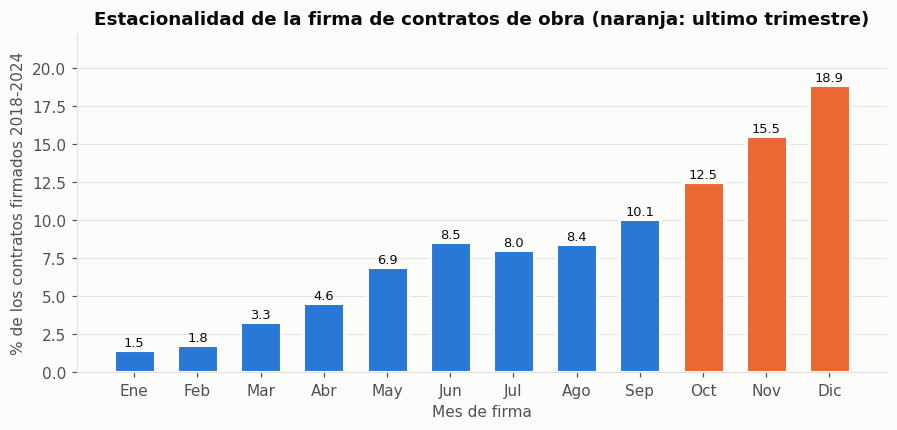

Figura persistida: 06_estacionalidad_mensual.png


In [9]:
marcar("fig_estacionalidad")

fig, ax = plt.subplots(figsize=(9.5, 4))
colores = [PALETA[1] if m in ("Oct", "Nov", "Dic") else PALETA[0] for m in mensual.index]
ax.bar(mensual.index, mensual["pct_del_total"], color=colores, width=0.65,
       edgecolor=SURFACE, linewidth=2)
for i, v in enumerate(mensual["pct_del_total"]):
    ax.text(i, v + 0.25, f"{v:.1f}", ha="center", fontsize=8.5, color=TEXT_1)
ax.set_ylabel("% de los contratos firmados 2018-2024")
ax.set_xlabel("Mes de firma")
ax.set_ylim(0, mensual["pct_del_total"].max() * 1.18)
ax.set_title("Estacionalidad de la firma de contratos de obra (naranja: ultimo trimestre)")
ax.xaxis.grid(False); ax.set_axisbelow(True)
guardar_mostrar(fig, "06_estacionalidad_mensual.png")

## 5. Momento de las modificaciones dentro del contrato

In [10]:
marcar("momento_modif")

d = df.copy()
d["fecha_primera_adicion"] = pd.to_datetime(d["fecha_primera_adicion"], errors="coerce")
d["fecha_ultima_adicion"] = pd.to_datetime(d["fecha_ultima_adicion"], errors="coerce")
d["dias_firma_a_primera_modificacion"] = (d["fecha_primera_adicion"] - d["fecha_firma"]).dt.days
d["ventana_modificaciones_dias"] = (d["fecha_ultima_adicion"] - d["fecha_primera_adicion"]).dt.days
d["fraccion_del_plazo_a_primera_modif"] = (
    d["dias_firma_a_primera_modificacion"] / d["plazo_contractual_final_dias"].replace(0, np.nan))

t = []
for etq, x in [("universo_completo", d), ("observable", d[d["observable"]])]:
    v = x["dias_firma_a_primera_modificacion"].dropna()
    w = x["ventana_modificaciones_dias"].dropna()
    fr = x["fraccion_del_plazo_a_primera_modif"].dropna()
    fr = fr[(fr >= 0) & (fr <= 3)]
    t.append({"lectura": etq,
              "N_ef_primera_modificacion": len(v),
              "mediana_dias_hasta_primera": v.median(),
              "p25": v.quantile(.25), "p75": v.quantile(.75),
              "N_ef_ventana": len(w), "mediana_ventana_dias": w.median(),
              "N_ef_fraccion": len(fr),
              "mediana_fraccion_del_plazo": round(fr.median(), 3)})
mom = pd.DataFrame(t)
print(mom.to_string(index=False))
print()
print("Lectura: la mediana de la fraccion del plazo transcurrida hasta la primera modificacion indica")
print("en que punto del contrato aparece el primer ajuste. Un valor cercano o superior a 1 significa")
print("que la modificacion llega al final o despues del plazo final vigente, lo que es coherente con")
print("prorrogas solicitadas cuando el contrato ya esta por vencer.")

          lectura  N_ef_primera_modificacion  mediana_dias_hasta_primera       p25     p75  N_ef_ventana  mediana_ventana_dias  N_ef_fraccion  mediana_fraccion_del_plazo
universo_completo                      33465                   -148.0000 -276.0000 58.0000         33465              245.0000          10824                      0.4260
       observable                      19194                   -112.0000 -261.0000 87.0000         19194              400.0000           6427                      0.4520

Lectura: la mediana de la fraccion del plazo transcurrida hasta la primera modificacion indica
en que punto del contrato aparece el primer ajuste. Un valor cercano o superior a 1 significa
que la modificacion llega al final o despues del plazo final vigente, lo que es coherente con
prorrogas solicitadas cuando el contrato ya esta por vencer.


## 6. Sintesis de hallazgos etiquetados

In [11]:
reg = RegistroHallazgos("06")
reg.add("H06-01",
        "El criterio temporal 2018-2024 excluye mayoritariamente contratacion POSTERIOR a 2024, no historia antigua",
        f"{int((excl['anio_firma'] > 2024).sum()):,} contratos posteriores a 2024 frente a {int((excl['anio_firma'] < 2018).sum()):,} anteriores a 2018",
        ref("anual"), ["A-OE03", "CALIDAD", "B-OE2"], "Alto",
        "Responde a la objecion de que el filtro 'descarta datos': descarta contratacion reciente aun no observable")
reg.add("H06-02",
        "La retencion del filtro de observabilidad cae fuertemente en los anios recientes",
        "Columna retencion_pct de la tabla anual", ref("anual"),
        ["A-OE03", "CALIDAD"], "Alto",
        "Es el efecto de truncamiento esperado y debe declararse como limitacion del corte")
reg.add("H06-03",
        "Los indicadores de desempeno NO son estables en el tiempo: el retraso material y la no entrega varian entre anios de forma significativa",
        "Kruskal-Wallis entre anios con epsilon2 reportado sobre el subconjunto observable",
        ref("estabilidad"), ["A-OE04", "B-OE2", "B-OE3-insumo"], "Alto",
        "El anio de firma es una variable con asociacion no trivial; conviene reportarlo junto a cualquier tasa global")
reg.add("H06-04",
        "La firma de contratos de obra esta concentrada en el ultimo trimestre del anio",
        "Tabla de estacionalidad mensual sobre 2018-2024", ref("estacionalidad"),
        ["A-OE04", "B-OE2"], "Medio",
        "Patron de ejecucion presupuestal de fin de vigencia; relevante para la interpretacion de la planeacion")
reg.add("H06-05",
        "La primera modificacion contractual aparece tipicamente cerca del final del plazo vigente",
        "Mediana de la fraccion del plazo transcurrida hasta la primera modificacion, en doble lectura",
        ref("momento_modif"), ["B-OE2", "B-OE3-insumo"], "Medio",
        "Recupera un analisis del pipeline compartido con derivacion propia; util como variable temporal")
reg.guardar()
reg.tabla()

,id,notebook,celda,hallazgo,evidencia,etiquetas,valor,nota
0,H06-01,06,c004,El criterio temporal 2018-2024 excluye mayorit...,"10,762 contratos posteriores a 2024 frente a 2...",[A-OE03] [CALIDAD] [B-OE2],Alto,Responde a la objecion de que el filtro 'desca...
1,H06-02,06,c004,La retencion del filtro de observabilidad cae ...,Columna retencion_pct de la tabla anual,[A-OE03] [CALIDAD],Alto,Es el efecto de truncamiento esperado y debe d...
2,H06-03,06,c007,Los indicadores de desempeno NO son estables e...,Kruskal-Wallis entre anios con epsilon2 report...,[A-OE04] [B-OE2] [B-OE3-insumo],Alto,El anio de firma es una variable con asociacio...
3,H06-04,06,c009,La firma de contratos de obra esta concentrada...,Tabla de estacionalidad mensual sobre 2018-2024,[A-OE04] [B-OE2],Medio,Patron de ejecucion presupuestal de fin de vig...
4,H06-05,06,c011,La primera modificacion contractual aparece ti...,Mediana de la fraccion del plazo transcurrida ...,[B-OE2] [B-OE3-insumo],Medio,Recupera un analisis del pipeline compartido c...


## Sintesis del notebook 06

| ID | Hallazgo | Etiquetas |
|---|---|---|
| H06-01 | El criterio 2018-2024 excluye mayoritariamente contratacion posterior a 2024, no historia antigua | `[A-OE03]` `[CALIDAD]` `[B-OE2]` |
| H06-02 | La retencion del filtro de observabilidad cae en los anios recientes: efecto de truncamiento | `[A-OE03]` `[CALIDAD]` |
| H06-03 | Los indicadores de desempeno no son estables entre anios | `[A-OE04]` `[B-OE2]` `[B-OE3-insumo]` |
| H06-04 | La firma se concentra en el ultimo trimestre del anio | `[A-OE04]` `[B-OE2]` |
| H06-05 | La primera modificacion aparece cerca del final del plazo vigente | `[B-OE2]` `[B-OE3-insumo]` |

**Productos persistidos:** `data/indicadores_por_anio.csv`, `figuras/06_distribucion_anual.png`,
`figuras/06_estabilidad_indicadores.png`, `figuras/06_estacionalidad_mensual.png`.